In [6]:
import pandas as pd 
import numpy as np 


from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

%matplotlib inline

In [7]:
df = pd.read_csv("../data/interim/appendicitis_clean.csv")
print(df.shape)
display(df.head(20))

(1500, 20)


,Age,Gender,BMI,Is_Pregnant,Duration_of_Symptoms_Hours,Pain_Migration,Abdominal_Pain_Location,Nausea_Vomiting,Loss_of_Appetite,Fever_Temp_C,Rebound_Tenderness,McBurney_Sign,Rovsing_Sign,Psoas_Sign,WBC_Count_k_uL,Neutrophil_Percentage,CRP_Level_mg_L,Ultrasound_Findings,Final_Diagnosis,target_bin
0,32,Female,23.4,0,17,1,RLQ,1,0,37.7,1,1,1,1,11.5,77.8,63.2,Non-visualized,Appendicitis,1
1,5,Male,19.4,0,31,0,RLQ,0,0,38.2,1,1,1,0,12.6,74.7,89.1,Target Sign,Appendicitis,1
2,28,Female,27.5,0,49,1,RLQ,1,1,37.7,1,1,0,1,16.2,77.0,92.9,Periappendiceal Fluid,Appendicitis,1
3,20,Male,28.7,0,32,0,RLQ,1,1,37.5,1,1,1,1,19.1,88.3,12.7,Periappendiceal Fluid,Appendicitis,1
4,12,Female,22.0,0,47,0,RLQ,0,0,37.3,0,0,1,0,12.2,65.0,8.8,Normal,Other (Ectopic Pregnancy (if pregnant)),0
5,21,Female,20.4,0,43,1,RLQ,1,1,37.5,1,0,1,0,11.3,81.5,34.8,Appendicolith Seen,Appendicitis,1
6,57,Male,28.9,0,19,1,Generalized,0,1,38.7,1,1,0,0,11.2,78.8,28.0,Enlarged (>6mm),Appendicitis,1
7,41,Female,28.7,0,28,1,Generalized,1,1,38.5,1,0,1,1,16.9,87.5,70.6,Periappendiceal Fluid,Appendicitis,1
8,21,Female,26.3,0,8,1,Generalized,1,1,37.9,1,1,1,0,14.4,82.9,199.8,Target Sign,Appendicitis,1
9,5,Female,20.6,0,29,0,RLQ,1,1,38.0,0,1,0,1,20.9,79.1,42.0,Enlarged (>6mm),Appendicitis,1


In [9]:
target_col = "Final_Diagnosis"
df["target_bin"] = (df[target_col] == "Appendicitis").astype(int)

In [11]:
df_feat = df.copy()

df_feat["Age_Group"] = pd.cut(
    df_feat["Age"],
    bins=[0, 12, 18, 35, 60, 120],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
    include_lowest =True
)


df_feat["BMI_Group"] = pd.cut(
    df_feat["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    include_lowest=True
)


df_feat["Symptoms_Positive_Count"] = (
    df_feat[["Pain_Migration", "Nausea_Vomiting", "Loss_of_Appetite", "Rebound_Tenderness", "McBurney_Sign", "Rovsing_Sign", "Psoas_Sign"]].sum(axis=1)
)

df_feat["Inflamation_Score"] = (
    df_feat["WBC_Count_k_uL"] + df_feat["Neutrophil_Percentage"] / 10  + df_feat["CRP_Level_mg_L"]
)

df_feat["Duration_Bucket"] = pd.cut(
    df_feat["Duration_of_Symptoms_Hours"],
    bins=[0, 6, 12, 24, 48, 1000],
    labels=["Very_Recent", "Recent", "12-24h", "Moderate", "Prolonged"],
    include_lowest=True
)


df_feat["Young_patient"] = (df_feat["Age"] <= 18).astype(int)
df_feat["High_CRP"] = (df_feat["CRP_Level_mg_L"] >= df_feat["CRP_Level_mg_L"].median()).astype(int)
df_feat["High_WBC"] = (df_feat["WBC_Count_k_uL"] >= df_feat["WBC_Count_k_uL"].median()).astype(int)

In [12]:
drop_cols = [target_col,  "target_bin"]
X_base = df.drop(columns=drop_cols, errors='ignore')
X_feat = df_feat.drop(columns=drop_cols, errors='ignore')
y= df_feat['target_bin']

print("Base shape:", X_base.shape)
print("Feature-engineered shape:", X_feat.shape)

Base shape: (1500, 18)
Feature-engineered shape: (1500, 26)


In [21]:
X_base_encoded = pd.get_dummies(X_base, drop_first=True)
print("Encoded feature-engineered shape:", X_base_encoded.shape)

Encoded feature-engineered shape: (1500, 29)


In [23]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

rows = []
for name, model in models.items():
    cv_out = cross_validate(model, X_base_encoded, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "cv_accuracy_mean": cv_out["test_accuracy"].mean(),
        "cv_precision_mean": cv_out["test_precision"].mean(),
        "cv_recall_mean": cv_out["test_recall"].mean(),
        "cv_f1_mean": cv_out["test_f1"].mean(),
        "cv_roc_auc_mean": cv_out["test_roc_auc"].mean(),
        "cv_pr_auc_mean": cv_out["test_pr_auc"].mean()
    })

feat_cv_df = pd.DataFrame(rows).sort_values(
    by=["cv_recall_mean", "cv_pr_auc_mean", "cv_f1_mean"],
    ascending=False
)
display(feat_cv_df.round(4))

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_pr_auc_mean
1,RandomForest,0.9980,0.9975,1.0000,0.9987,1.0000,1.0000
2,GradientBoosting,0.9947,0.9950,0.9983,0.9966,0.9999,1.0000
0,LogisticRegression,0.9973,0.9983,0.9983,0.9983,0.9997,0.9999


In [22]:
base_rows = []

for name, model in models.items():
    cv_out = cross_validate(model, X_base_encoded, y, cv=cv, scoring=scoring, n_jobs=-1)
    base_rows.append({
        "model": name,
        "cv_accuracy_mean": cv_out["test_accuracy"].mean(),
        "cv_precision_mean": cv_out["test_precision"].mean(),
        "cv_recall_mean": cv_out["test_recall"].mean(),
        "cv_f1_mean": cv_out["test_f1"].mean(),
        "cv_roc_auc_mean": cv_out["test_roc_auc"].mean(),
        "cv_pr_auc_mean": cv_out["test_pr_auc"].mean()
    })
    

base_cv_df = pd.DataFrame(base_rows).sort_values(
    by=["cv_recall_mean", "cv_pr_auc_mean", "cv_f1_mean"],
    ascending=False
)
display(base_cv_df.round(4))


,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_pr_auc_mean
1,RandomForest,0.9980,0.9975,1.0000,0.9987,1.0000,1.0000
2,GradientBoosting,0.9947,0.9950,0.9983,0.9966,0.9999,1.0000
0,LogisticRegression,0.9973,0.9983,0.9983,0.9983,0.9997,0.9999


In [24]:
compare_df = base_cv_df.merge(
    feat_cv_df,
    on="model",
    suffixes=("_base", "_feat")
)


compare_df["recall_diff"] = compare_df["cv_recall_mean_feat"] - compare_df["cv_recall_mean_base"]
compare_df["pr_auc_diff"] = compare_df["cv_pr_auc_mean_feat"] - compare_df["cv_pr_auc_mean_base"]
compare_df["f1_diff"] = compare_df["cv_f1_mean_feat"] - compare_df["cv_f1_mean_base"]

display(compare_df.round(4))

,model,cv_accuracy_mean_base,cv_precision_mean_base,cv_recall_mean_base,cv_f1_mean_base,cv_roc_auc_mean_base,cv_pr_auc_mean_base,cv_accuracy_mean_feat,cv_precision_mean_feat,cv_recall_mean_feat,cv_f1_mean_feat,cv_roc_auc_mean_feat,cv_pr_auc_mean_feat,recall_diff,pr_auc_diff,f1_diff
0,RandomForest,0.9980,0.9975,1.0000,0.9987,1.0000,1.0000,0.9980,0.9975,1.0000,0.9987,1.0000,1.0000,0.0,0.0,0.0
1,GradientBoosting,0.9947,0.9950,0.9983,0.9966,0.9999,1.0000,0.9947,0.9950,0.9983,0.9966,0.9999,1.0000,0.0,0.0,0.0
2,LogisticRegression,0.9973,0.9983,0.9983,0.9983,0.9997,0.9999,0.9973,0.9983,0.9983,0.9983,0.9997,0.9999,0.0,0.0,0.0


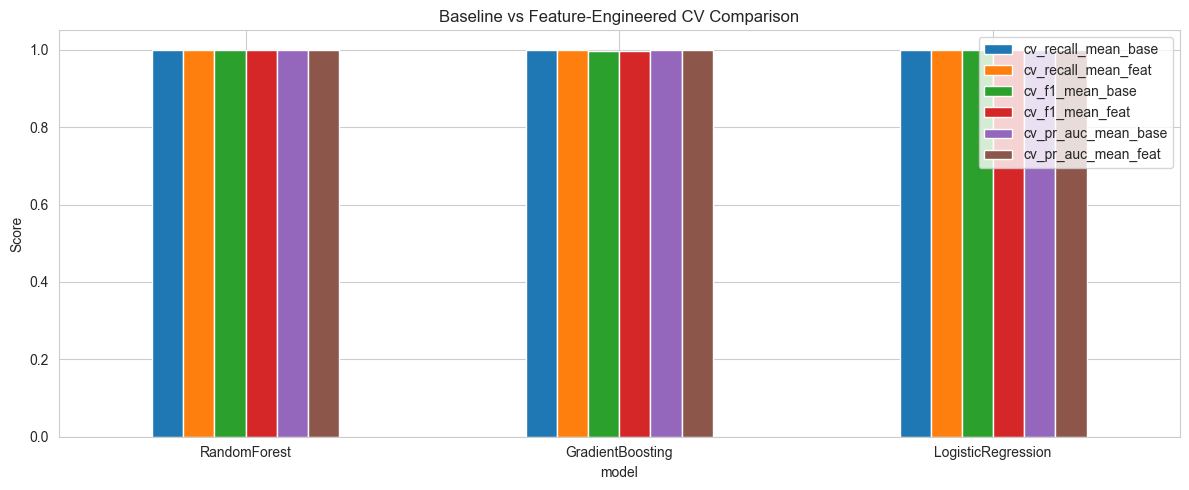

In [25]:
metric_cols = [
    "cv_recall_mean_base", "cv_recall_mean_feat",
    "cv_f1_mean_base", "cv_f1_mean_feat",
    "cv_pr_auc_mean_base", "cv_pr_auc_mean_feat"
]

compare_df_plot = compare_df.set_index("model")[metric_cols]
compare_df_plot.plot(kind="bar", figsize=(12, 5))
plt.title("Baseline vs Feature-Engineered CV Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_feat.to_csv("../data/interim/appendicitis_feature_engineered.csv", index=False)
print("Saved feature-engineered dataset to ../data/interim/appendicitis_feature_engineered.csv")